In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_excel("IMDb Movies India.xlsx")

In [4]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
df.shape

(15509, 10)

In [6]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [8]:
df.describe()

,Year,Rating
count,14981.000000,7919.000000
mean,-1987.012215,5.841621
std,25.416689,1.381777
min,-2022.000000,1.100000
25%,-2009.000000,4.900000
50%,-1991.000000,6.000000
75%,-1968.000000,6.800000
max,-1913.000000,10.000000


In [9]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [10]:
df = df.dropna(subset=["Rating"])

In [11]:
df["Genre"] = df["Genre"].fillna("Unknown")
df["Director"] = df["Director"].fillna("Unknown")

df["Actor 1"] = df["Actor 1"].fillna("Unknown")
df["Actor 2"] = df["Actor 2"].fillna("Unknown")
df["Actor 3"] = df["Actor 3"].fillna("Unknown")

In [12]:
df["Votes"] = df["Votes"].astype(str).str.replace(",", "")

In [13]:
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

In [14]:
df["Votes"] = df["Votes"].fillna(df["Votes"].median())

In [15]:
df["Duration"] = df["Duration"].astype(str).str.replace(" min", "")

In [16]:
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

In [17]:
df["Duration"] = df["Duration"].fillna(df["Duration"].median())

In [18]:
df["Year"] = df["Year"].astype(str).str.extract("(\d{4})")

In [19]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [20]:
df["Year"] = df["Year"].fillna(df["Year"].median())

In [21]:
encoder = LabelEncoder()

In [22]:
df["Genre"] = encoder.fit_transform(df["Genre"])

df["Director"] = encoder.fit_transform(df["Director"])

df["Actor 1"] = encoder.fit_transform(df["Actor 1"])

df["Actor 2"] = encoder.fit_transform(df["Actor 2"])

df["Actor 3"] = encoder.fit_transform(df["Actor 3"])

In [23]:
X = df[["Year",
        "Duration",
        "Votes",
        "Genre",
        "Director",
        "Actor 1",
        "Actor 2",
        "Actor 3"]]


In [24]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,268,7.0,8,811,1782,2815,377
3,#Yaaram,2019,110.0,207,4.4,35,1749,1589,890,2572
5,...Aur Pyaar Ho Gaya,1997,147.0,177,4.7,827,2005,508,85,2449
6,...Yahaan,2005,142.0,331,7.4,1086,2643,931,1388,3030
8,?: A Question Mark,2012,82.0,367,5.6,326,174,2521,1461,1205


In [25]:
y = df["Rating"]

In [26]:
y.head()

1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print(X_train.shape)
print(X_test.shape)

(6335, 8)
(1584, 8)


In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred = model.predict(X_test)

In [32]:
print(y_pred[:10])

[5.92222862 5.50536892 5.20277622 5.75410558 5.78922586 5.52768836
 6.11162393 5.78863954 6.13470498 5.91713444]


In [33]:
comparison = pd.DataFrame({
    "Actual Rating": y_test,
    "Predicted Rating": y_pred
})

comparison.head(10)

,Actual Rating,Predicted Rating
9456,3.3,5.922229
14816,5.3,5.505369
3213,5.7,5.202776
3778,7.2,5.754106
5775,3.5,5.789226
12203,7.2,5.527688
12305,3.8,6.111624
4650,6.9,5.788640
8701,5.2,6.134705
4707,7.4,5.917134


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [35]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.0312466227047665


In [36]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.2930562529415488


In [37]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.10066490414331852


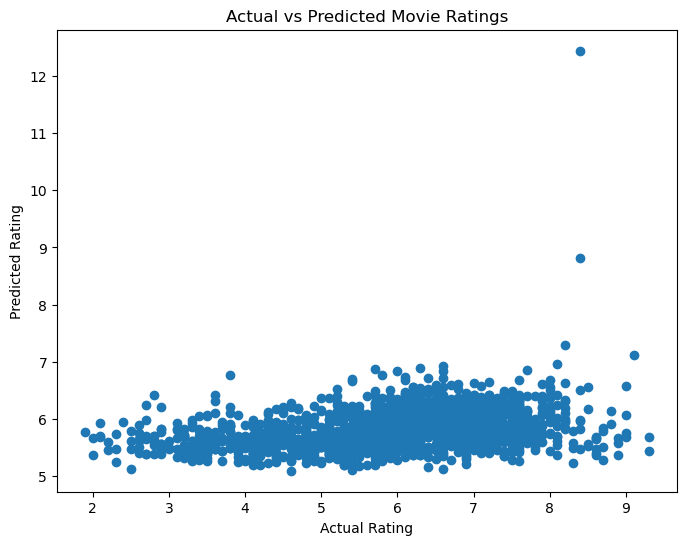

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()

In [39]:
import joblib
joblib.dump(model, "movie_rating_model.pkl")

['movie_rating_model.pkl']

In [40]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.0312466227047665
RMSE: 1.2930562529415488
R2 Score: 0.10066490414331852
